<h1 style="text-align: center;">Notebook for Data Analysis</h1>

In [1]:
import numpy as np
import modred as mr
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.fft import fft, ifft

import data_analysis
import importlib
importlib.reload(data_analysis)

import utils
importlib.reload(utils)

%matplotlib inline
matplotlib.pyplot.rc('text', usetex=True)

fontsize = 18

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib
import math
import os 
import torch.nn.functional as F

import importlib
import data_analysis
importlib.reload(data_analysis)

import autoencoder
importlib.reload(autoencoder)

import utils
importlib.reload(utils)

%matplotlib inline
matplotlib.pyplot.rc('text', usetex=True)
fontsize = 18


print(f'Working in {os.getcwd()}')

Working in /projects/IceDynamics/Stage_M2/code


# 

In [34]:
from data_analysis import Simulation
from utils import compatible_path
current_directory = compatible_path('../')

Ra = 1e8
Lambda = 0.0
simulation = Simulation(current_directory, Ra = Ra, Lambda = Lambda)
time, x, z, u, w, T, umean, wmean, Tmean = simulation.import_data(mean_type='scaled')
simulation.image_rgb()


data from ..//data/bulk_L0.0_Ra8.npz
X shape (10136, 12393)


In [35]:
simulation.X_rgb.shape

(10136, 3, 81, 51)

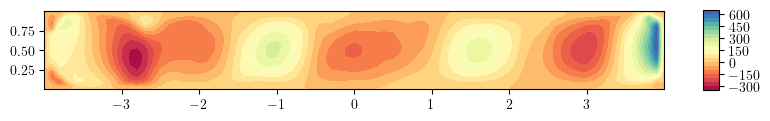

In [3]:
simulation.plot_meancomponent(component = 'w')

In [4]:
uz, uzmean = simulation.UZ()

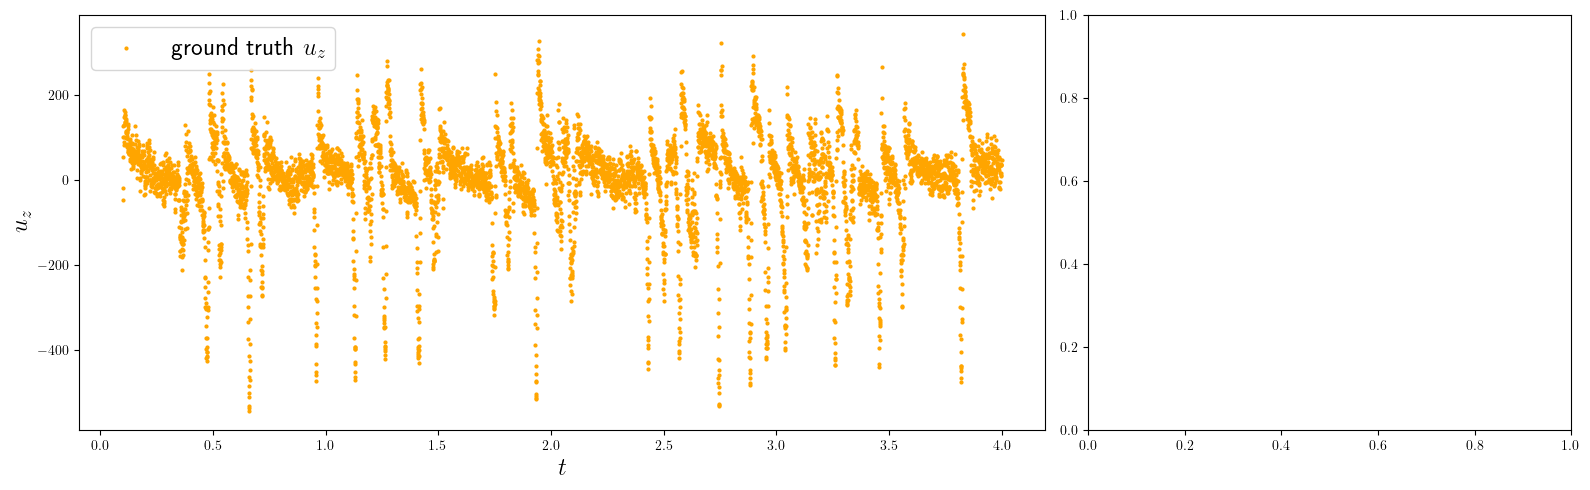

In [5]:
fig, [ax1,ax2] = plt.subplots(1,2,figsize = (16, 5), gridspec_kw={'width_ratios': [2, 1]})

ax1.scatter(time, uz, s = 4, c = 'orange', label = r'ground truth $u_z$')
ax1.set_ylabel(r'$u_z$', fontsize= fontsize)
ax1.set_xlabel(r'$t$', fontsize = fontsize)
ax1.legend(fontsize = fontsize, loc = 'upper left')


fig.tight_layout()

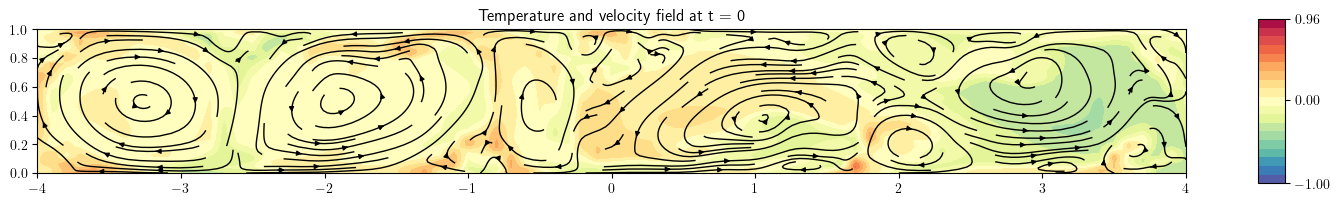

In [6]:
t = 0
simulation.plot_field(t= t)

In [7]:
# for t in range(0, 500, 2):
#     simulation.plot_field(t, save = True, directory = current_directory + '/results/data_analysis/gt_L1000_Ra7/' + f"snapshot{t}")

# from utils import make_gif
# make_gif('../results/data_analysis/gt_L1000_Ra7/', '../results/gif/data_analysis/gt_L1000_Ra7.gif', fps = 10)

# FFT raw simulation

In [10]:
X = np.swapaxes(np.swapaxes(np.swapaxes(simulation.X_rgb, 0,1), 1, 2), 2, 3)
print(X.shape)

(3, 81, 51, 6249)


In [15]:
simulation.x[0,:]

array([-3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999, -3.9999999, -3.9999999, -3.9999999, -3.9999999,
       -3.9999999])

In [9]:
simulation.X_rgb.shape

(6249, 3, 81, 51)

In [11]:
X_fft = fft(X)
print(X_fft.shape)

(3, 81, 51, 6249)


In [11]:
X_fft.shape

(3, 81, 51, 6249)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


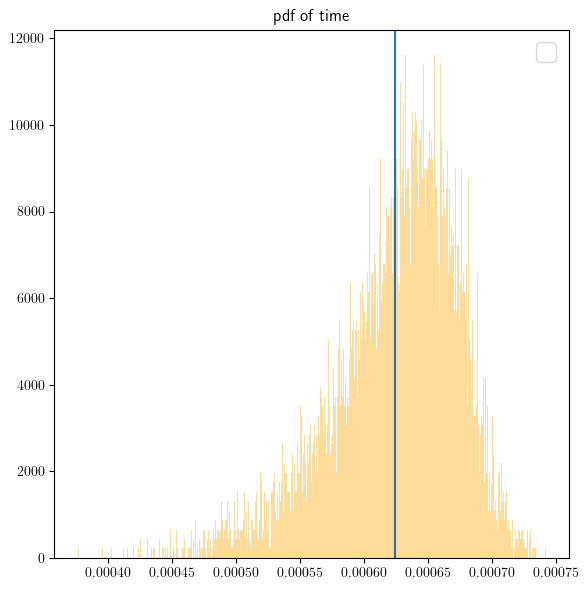

In [17]:
time_intervals = time[1:]-time[:-1]

sample_spacing = np.mean(time_intervals)
fig, ax = plt.subplots(figsize = (6,6))

ax.hist(time_intervals, bins=500, density=True, alpha=0.4, color='orange', histtype = 'bar')
plt.axvline(sample_spacing)
ax.set_title(f'pdf of time')
plt.tight_layout()
plt.legend(fontsize= fontsize)
plt.show()

In [13]:
flow_fft = np.fft.fftn(X)
freq = np.fft.fftfreq(X.shape[3], d=sample_spacing)

In [14]:
print(flow_fft.shape)
print(freq.shape)

(3, 81, 51, 6249)
(6249,)


In [19]:
dx = x[1:,0]-x[:-1,0]
dx = dx[0]
dz = z[0,1:]-z[0,:-1]
dz = dz[0]
print(dx)

0.09999999749999988


[0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02]


In [17]:
horizontal_fft = np.fft.fftn(X[0,:,:,:])
horizontal_fft = np.fft.fftshift(horizontal_fft)
vertical_fft = np.fft.fftn(X[1,:,:,:])
vertical_fft = np.fft.fftshift(vertical_fft)


horizontal_psd = np.abs(horizontal_fft)**2
vertical_psd = np.abs(vertical_fft)**2

turbulence_spectrum = horizontal_psd + vertical_psd
average_time_interval = np.mean(time_intervals)

freqList = np.fft.fftfreq(X.shape[3], d=average_time_interval)*2*np.pi
freqList = np.fft.fftshift(freqList)


kzList = np.fft.fftfreq(X.shape[2], d=dz)*2*np.pi
kzList = np.fft.fftshift(kzList)
kxList = np.fft.fftfreq(X.shape[1], d=dx)*2*np.pi
kxList = np.fft.fftshift(kxList)

In [21]:
turbulence_spectrum.shape

(81, 6249)

In [23]:
print(horizontal_fft.shape)
print(kxList.shape)
print(X.shape)

(81, 6249)
(81,)
(3, 81, 51, 6249)


In [ ]:
print(horizontal_fft.shape)
print(kzList.shape)
print(freqList.shape)

(81, 51, 6249)
(51,)
(6249,)


In [ ]:
np.shape(np.meshgrid(kzList, freqList))

(2, 6249, 51)

In [ ]:
np.meshgrid(kzList, freqList)

[array([[-153.99967068, -147.83968385, -141.67969703, ...,  141.67969703,
          147.83968385,  153.99967068],
        [-153.99967068, -147.83968385, -141.67969703, ...,  141.67969703,
          147.83968385,  153.99967068],
        [-153.99967068, -147.83968385, -141.67969703, ...,  141.67969703,
          147.83968385,  153.99967068],
        ...,
        [-153.99967068, -147.83968385, -141.67969703, ...,  141.67969703,
          147.83968385,  153.99967068],
        [-153.99967068, -147.83968385, -141.67969703, ...,  141.67969703,
          147.83968385,  153.99967068],
        [-153.99967068, -147.83968385, -141.67969703, ...,  141.67969703,
          147.83968385,  153.99967068]]),
 array([[-5032.79558278, -5032.79558278, -5032.79558278, ...,
         -5032.79558278, -5032.79558278, -5032.79558278],
        [-5031.18457267, -5031.18457267, -5031.18457267, ...,
         -5031.18457267, -5031.18457267, -5031.18457267],
        [-5029.57356256, -5029.57356256, -5029.57356256, ...,

In [ ]:
np.meshgrid(kzList, freqList)[1]

array([[-5032.79558278, -5032.79558278, -5032.79558278, ...,
        -5032.79558278, -5032.79558278, -5032.79558278],
       [-5031.18457267, -5031.18457267, -5031.18457267, ...,
        -5031.18457267, -5031.18457267, -5031.18457267],
       [-5029.57356256, -5029.57356256, -5029.57356256, ...,
        -5029.57356256, -5029.57356256, -5029.57356256],
       ...,
       [ 5029.57356256,  5029.57356256,  5029.57356256, ...,
         5029.57356256,  5029.57356256,  5029.57356256],
       [ 5031.18457267,  5031.18457267,  5031.18457267, ...,
         5031.18457267,  5031.18457267,  5031.18457267],
       [ 5032.79558278,  5032.79558278,  5032.79558278, ...,
         5032.79558278,  5032.79558278,  5032.79558278]])

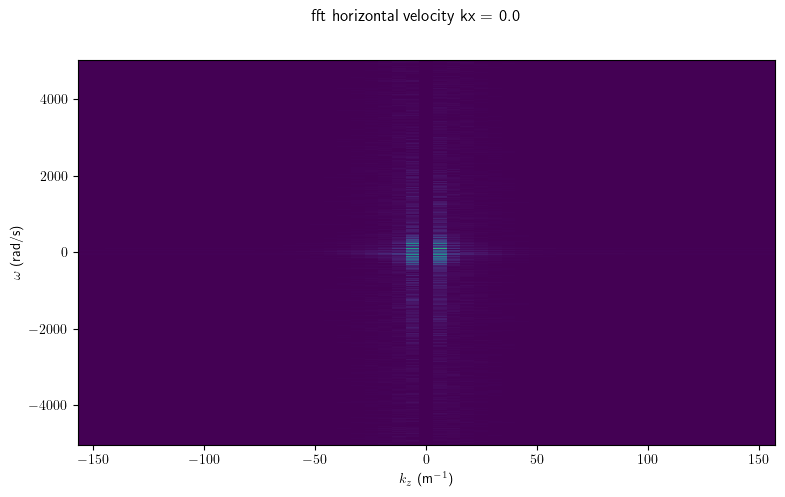

In [19]:
fig, ax = plt.subplots()
kx = 40
# plt.imshow(avgVelFT)
fig.suptitle(f'fft horizontal velocity kx = {kxList[kx]}')

x_mesh,y_mesh = np.meshgrid(kzList, freqList)
a0 = ax.pcolormesh(x_mesh, y_mesh, np.abs(horizontal_fft[kx, :, :].T))
# addColorbar(ax, artist=a0, clabel=r'$|\mathbf{v}|^2(\omega, \mathbf{k})$')
# clabel=r'$\langle|\mathbf{v}(\mathbf{r},t)|\rangle_y$'
ax.set_ylabel(r'$\omega$ (rad/s)')
ax.set_xlabel(r'$k_z$ (m$^{-1}$)')
fig.set_size_inches(9, 5)

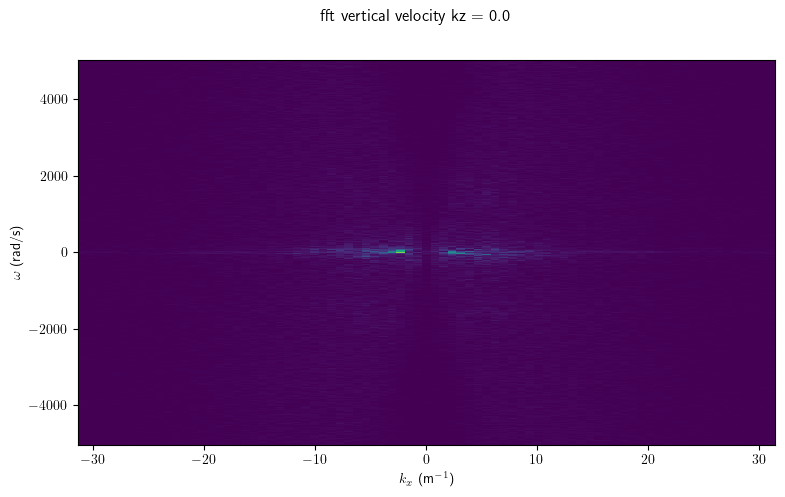

In [20]:
fig, ax = plt.subplots()
kz = 25
# plt.imshow(avgVelFT)
# fig.suptitle(r'$k_y = ' + str(np.round(kyList[kyInd], 2)) + '\ \mathrm{m}^{-1}$', x=.51, y=.95)
fig.suptitle(f'fft vertical velocity kz = {kzList[kz]}')

x_mesh,y_mesh = np.meshgrid(kxList, freqList)
a0 = ax.pcolormesh(x_mesh, y_mesh, np.abs(horizontal_fft[:, kz, :].T))
# addColorbar(ax, artist=a0, clabel=r'$|\mathbf{v}|^2(\omega, \mathbf{k})$')
# clabel=r'$\langle|\mathbf{v}(\mathbf{r},t)|\rangle_y$'
ax.set_ylabel(r'$\omega$ (rad/s)')
ax.set_xlabel(r'$k_x$ (m$^{-1}$)')
fig.set_size_inches(9, 5)

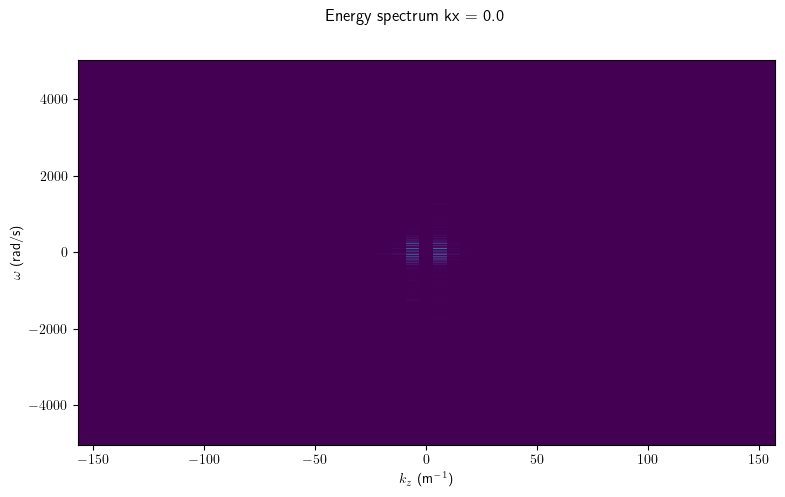

In [21]:
fig, ax = plt.subplots()
kx = 40
# plt.imshow(avgVelFT)
# fig.suptitle(r'$k_y = ' + str(np.round(kyList[kyInd], 2)) + '\ \mathrm{m}^{-1}$', x=.51, y=.95)
fig.suptitle(f'Energy spectrum kx = {kxList[kx]}')

x_mesh,y_mesh = np.meshgrid(kzList, freqList)
a0 = ax.pcolormesh(x_mesh, y_mesh, np.abs(turbulence_spectrum[kx, :, :].T))
# addColorbar(ax, artist=a0, clabel=r'$|\mathbf{v}|^2(\omega, \mathbf{k})$')
# clabel=r'$\langle|\mathbf{v}(\mathbf{r},t)|\rangle_y$'
ax.set_ylabel(r'$\omega$ (rad/s)')
ax.set_xlabel(r'$k_z$ (m$^{-1}$)')
fig.set_size_inches(9, 5)

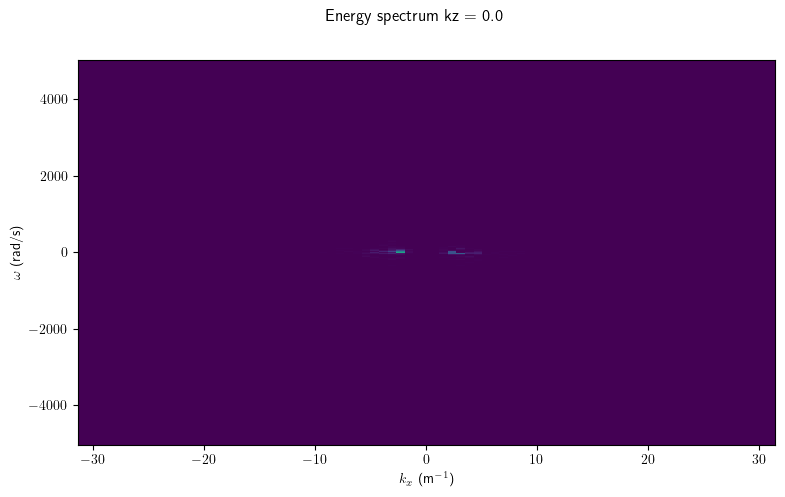

In [22]:
fig, ax = plt.subplots()
kz = 25
# plt.imshow(avgVelFT)
# fig.suptitle(r'$k_y = ' + str(np.round(kyList[kyInd], 2)) + '\ \mathrm{m}^{-1}$', x=.51, y=.95)

fig.suptitle(f'Energy spectrum kz = {kzList[kz]}')
x_mesh,y_mesh = np.meshgrid(kxList, freqList)
a0 = ax.pcolormesh(x_mesh, y_mesh, np.abs(turbulence_spectrum[:, kz, :].T))
# addColorbar(ax, artist=a0, clabel=r'$|\mathbf{v}|^2(\omega, \mathbf{k})$')
# clabel=r'$\langle|\mathbf{v}(\mathbf{r},t)|\rangle_y$'
ax.set_ylabel(r'$\omega$ (rad/s)')
ax.set_xlabel(r'$k_x$ (m$^{-1}$)')
fig.set_size_inches(9, 5)

In [23]:
turbulence_spectrum_integrated = np.sum(turbulence_spectrum, axis=(0, 1))
print(turbulence_spectrum_integrated.shape)

(6249,)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


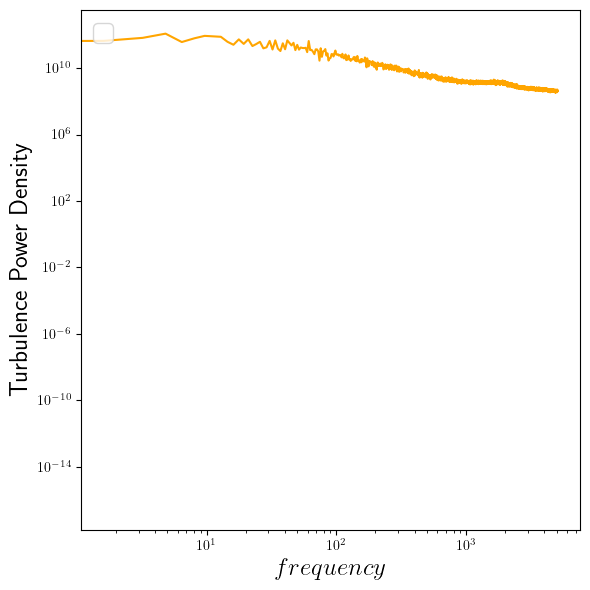

In [24]:
fig, ax1 = plt.subplots(figsize = (6,6))

ax1.plot(freqList, turbulence_spectrum_integrated, c = 'orange')
ax1.set_ylabel(r'Turbulence Power Density', fontsize= fontsize)
ax1.set_xlabel(r'$frequency$', fontsize = fontsize)
ax1.legend(fontsize = fontsize, loc = 'upper left')
ax1.set_yscale('log') 
ax1.set_xscale('log') 

fig.tight_layout()

In [70]:
def spectrum(simu, x, z):
    dx = x[1:,0]-x[:-1,0]
    dx = dx[0]
    dz = z[0,1:]-z[0,:-1]
    dz = dz[0]
    X = np.swapaxes(np.swapaxes(np.swapaxes(simu.X_rgb, 0,1), 1, 2), 2, 3)
    horizontal_fft = np.fft.fftn(X[0,:,26,:])
    horizontal_fft = np.fft.fftshift(horizontal_fft)
    vertical_fft = np.fft.fftn(X[1,:,26,:])
    vertical_fft = np.fft.fftshift(vertical_fft)
    time_intervals = time[1:]-time[:-1]

    horizontal_psd = np.abs(horizontal_fft)**2
    vertical_psd = np.abs(vertical_fft)**2

    turbulence_spectrum = horizontal_psd + vertical_psd
    average_time_interval = np.mean(time_intervals)

    freqList = np.fft.fftfreq(X.shape[3], d=average_time_interval)*2*np.pi
    freqList = np.fft.fftshift(freqList)


    kzList = np.fft.fftfreq(X.shape[2], d=dz)*2*np.pi
    kzList = np.fft.fftshift(kzList)
    kxList = np.fft.fftfreq(X.shape[1], d=dx)*2*np.pi
    kxList = np.fft.fftshift(kxList)
    turbulence_spectrum_integrated = np.sum(turbulence_spectrum, axis=(1))
    cumulative_power_density = np.cumsum(turbulence_spectrum_integrated)
    return kxList, turbulence_spectrum_integrated, cumulative_power_density

In [24]:
turbulence_spectrum.shape

(81, 6249)

In [25]:

print(turbulence_spectrum_integrated.shape)

(81,)


In [81]:


Ra = 1e8
Lambda = 1000.0
simulation = Simulation(current_directory, Ra = Ra, Lambda = 1e-2)
time, x, z, u, w, T, umean, wmean, Tmean = simulation.import_data(mean_type='scaled')
simulation.image_rgb()

simulation_1000 = Simulation(current_directory, Ra = Ra, Lambda = 1000.0)
time, x, z, u, w, T, umean, wmean, Tmean = simulation_1000.import_data(mean_type='scaled')
simulation_1000.image_rgb()
simulation_0 = Simulation(current_directory, Ra = Ra, Lambda = 0.0)
time, x, z, u, w, T, umean, wmean, Tmean = simulation_0.import_data(mean_type='scaled')
simulation_0.image_rgb()

simulation_pandey = Simulation(current_directory, Ra = Ra, pandey=True)
simulation_pandey.import_data_pandey()

data from ..//data/bulk_L0.01_Ra8.npz
X shape (6249, 12393)
data from ..//data/bulk_L1000.0_Ra8.npz
X shape (23724, 12393)
data from ..//data/bulk_L0.0_Ra8.npz
X shape (10136, 12393)


In [82]:
kxList_1000, turbulence_spectrum_integrated_1000, cumulative_spectrum_1000 = spectrum(simulation_1000, x, z)
kxList_0, turbulence_spectrum_integrated_0, cumulative_spectrum_0 = spectrum(simulation_0, x, z)
kxList, turbulence_spectrum_integrated, cumulative_spectrum = spectrum(simulation, x, z)
kxList_pandey, turbulence_spectrum_integrated_pandey, cumulative_spectrum_pandey = spectrum(simulation, x, z)

In [49]:
print(kxList_1000)

[-31.02807637 -30.25237446 -29.47667255 -28.70097064 -27.92526873
 -27.14956682 -26.37386491 -25.598163   -24.82246109 -24.04675918
 -23.27105728 -22.49535537 -21.71965346 -20.94395155 -20.16824964
 -19.39254773 -18.61684582 -17.84114391 -17.065442   -16.28974009
 -15.51403818 -14.73833627 -13.96263437 -13.18693246 -12.41123055
 -11.63552864 -10.85982673 -10.08412482  -9.30842291  -8.532721
  -7.75701909  -6.98131718  -6.20561527  -5.42991336  -4.65421146
  -3.87850955  -3.10280764  -2.32710573  -1.55140382  -0.77570191
   0.           0.77570191   1.55140382   2.32710573   3.10280764
   3.87850955   4.65421146   5.42991336   6.20561527   6.98131718
   7.75701909   8.532721     9.30842291  10.08412482  10.85982673
  11.63552864  12.41123055  13.18693246  13.96263437  14.73833627
  15.51403818  16.28974009  17.065442    17.84114391  18.61684582
  19.39254773  20.16824964  20.94395155  21.71965346  22.49535537
  23.27105728  24.04675918  24.82246109  25.598163    26.37386491
  27.1495668

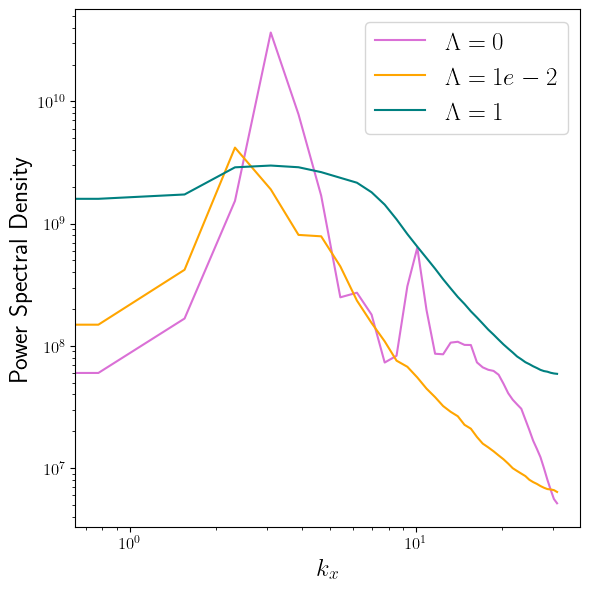

In [91]:
fig, ax1 = plt.subplots(figsize = (6,6))

ax1.plot(kxList, turbulence_spectrum_integrated_0, c = 'orchid', label = r'$\Lambda = 0$')
ax1.plot(kxList, turbulence_spectrum_integrated, c = 'orange',label = r'$\Lambda = 1e-2$' )
ax1.plot(kxList, turbulence_spectrum_integrated_1000, c = 'teal', label = r'$\Lambda = 1$')
ax1.set_ylabel(r'Power Spectral Density', fontsize= fontsize)
ax1.set_xlabel(r'$k_x$', fontsize = fontsize)
ax1.legend(fontsize = fontsize)
ax1.set_yscale('log') 
ax1.set_xscale('log') 

tick_fontsize = 12
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        

fig.tight_layout()

In [85]:

fig, ax1 = plt.subplots(figsize = (6,6))

ax1.plot(kxList_pandey, turbulence_spectrum_integrated_pandey, c = 'teal', label = r'$Data from Pandey et al.')
ax1.set_ylabel(r'Power Spectral Density', fontsize= fontsize)
ax1.set_xlabel(r'$k_x$', fontsize = fontsize)
ax1.legend(fontsize = fontsize)
ax1.set_yscale('log') 
ax1.set_xscale('log') 

tick_fontsize = 12
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        

fig.tight_layout()

RuntimeError: latex was not able to process the following string:
b'$Data from Pandey et al.'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpofx4slrz 2f6e49fb4983b67fc37be9bae66f4ca0.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.24 (TeX Live 2022/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./2f6e49fb4983b67fc37be9bae66f4ca0.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-01-16>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty

Error in callback <function _draw_all_if_interactive at 0x7fde98951da0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'$Data from Pandey et al.'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpqnz3w59h 2f6e49fb4983b67fc37be9bae66f4ca0.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.24 (TeX Live 2022/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./2f6e49fb4983b67fc37be9bae66f4ca0.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-01-16>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty

RuntimeError: latex was not able to process the following string:
b'$Data from Pandey et al.'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpu_xisrlo 2f6e49fb4983b67fc37be9bae66f4ca0.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.24 (TeX Live 2022/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./2f6e49fb4983b67fc37be9bae66f4ca0.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-01-16>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty

<Figure size 600x600 with 1 Axes>

In [74]:
cumulative_spectrum_0/cumulative_spectrum_0[-1]

array([5.02467845e-05, 1.04713912e-04, 1.69505993e-04, 2.47915219e-04,
       3.45260613e-04, 4.65123283e-04, 6.05343265e-04, 7.68905994e-04,
       9.68903078e-04, 1.21245242e-03, 1.51087005e-03, 1.83480733e-03,
       2.18861981e-03, 2.58855535e-03, 3.06692598e-03, 3.63343408e-03,
       4.24230165e-03, 4.86426474e-03, 5.51539083e-03, 6.23027050e-03,
       7.22218450e-03, 8.21639917e-03, 9.27099971e-03, 1.03084126e-02,
       1.11411811e-02, 1.19823537e-02, 1.38972889e-02, 2.01108354e-02,
       2.31109249e-02, 2.39206682e-02, 2.46334615e-02, 2.63915413e-02,
       2.90493045e-02, 3.14861440e-02, 4.80476987e-02, 1.24676029e-01,
       4.82649848e-01, 4.97651309e-01, 4.99285227e-01, 4.99871098e-01,
       5.00128902e-01, 5.00714773e-01, 5.02348691e-01, 5.17350152e-01,
       8.75323971e-01, 9.51952301e-01, 9.68513856e-01, 9.70950695e-01,
       9.73608459e-01, 9.75366538e-01, 9.76079332e-01, 9.76889075e-01,
       9.79889165e-01, 9.86102711e-01, 9.88017646e-01, 9.88858819e-01,
      

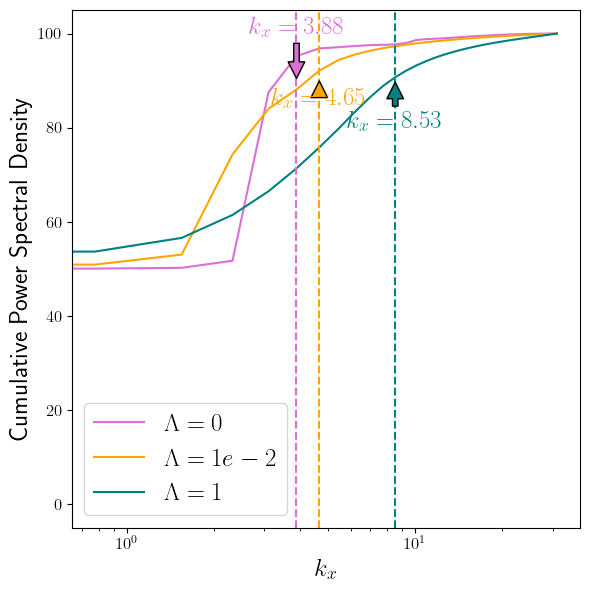

In [93]:
fig, ax1 = plt.subplots(figsize = (6,6))

ax1.plot(kxList, 100 * cumulative_spectrum_0/cumulative_spectrum_0[-1], c = 'orchid', label = r'$\Lambda = 0$')
ax1.plot(kxList, 100 *cumulative_spectrum/cumulative_spectrum[-1], c = 'orange',label = r'$\Lambda = 1e-2$' )
ax1.plot(kxList, 100 *cumulative_spectrum_1000/cumulative_spectrum_1000[-1], c = 'teal', label = r'$\Lambda = 1$')
ax1.set_ylabel(r'Cumulative Power Spectral Density', fontsize= fontsize)
ax1.set_xlabel(r'$k_x$', fontsize = fontsize)
ax1.legend(fontsize = fontsize)
# ax1.set_yscale('log') 
ax1.set_xscale('log') 

tick_fontsize = 12
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        
ax1.axvline(x=kx_90, color='orange', linestyle='--')
ax1.axvline(x=kx_90_0, color='orchid', linestyle='--')
ax1.axvline(x=kx_90_1000, color='teal', linestyle='--')

ax1.annotate(f'$k_x = {kx_90:.2f}$', xy=(kx_90, 90), xytext=(kx_90, 85),
             arrowprops=dict(facecolor='orange', shrink=0.05), fontsize=fontsize, color='orange', ha='center')
ax1.annotate(f'$k_x = {kx_90_0:.2f}$', xy=(kx_90_0, 90), xytext=(kx_90_0, 100),
             arrowprops=dict(facecolor='orchid', shrink=0.05), fontsize=fontsize, color='orchid', ha='center')
ax1.annotate(f'$k_x = {kx_90_1000:.2f}$', xy=(kx_90_1000, 90), xytext=(kx_90_1000, 80),
             arrowprops=dict(facecolor='teal', shrink=0.05), fontsize=fontsize, color='teal', ha='center')

fig.tight_layout()

In [87]:

def find_kx_for_cpsd_90(CPSD):
    cpsd_90_value = 0.9 * CPSD[-1]
    idx_90 = np.where(CPSD >= cpsd_90_value)[0][0]
    return kxList[idx_90], cpsd_90_value

kx_90, cpsd_90 = find_kx_for_cpsd_90(cumulative_spectrum)
kx_90_0, cpsd_90_0 = find_kx_for_cpsd_90(cumulative_spectrum_0)
kx_90_1000, cpsd_90_1000 = find_kx_for_cpsd_90(cumulative_spectrum_1000)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


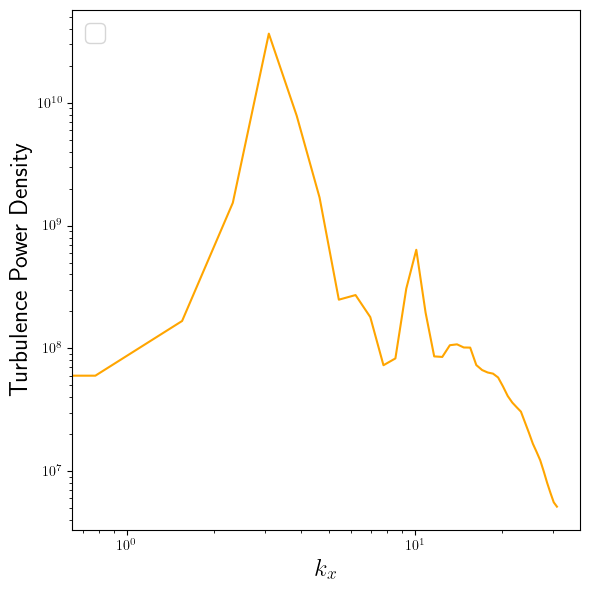

In [40]:
fig, ax1 = plt.subplots(figsize = (6,6))

ax1.plot(kxList, turbulence_spectrum_integrated, c = 'orange')
ax1.set_ylabel(r'Turbulence Power Density', fontsize= fontsize)
ax1.set_xlabel(r'$k_x$', fontsize = fontsize)
ax1.legend(fontsize = fontsize, loc = 'upper left')
ax1.set_yscale('log') 
ax1.set_xscale('log') 

fig.tight_layout()

# On AE

In [25]:
from utils import get_freer_gpu

device = get_freer_gpu() if torch.cuda.is_available() else "cpu"

Selected GPU 1 with 48673 MB free memory 


K: 128
batch_size: 4
size1: (40, 25)
size2: (20, 12)
size3: (10, 6)
size4: (5, 3)
thirty_min_epoch: None
num_epoch: 100
lr: 0.0001
weight_decay: 0
execution_time_in_min: 34.60871301094691
epoch_1: {'loss': 0.01800575666129589, 'nmse': 0.8128084421157837, 'time': 0.3926729996999105}
epoch_2: {'loss': 0.014275999739766121, 'nmse': 0.5385298132896423, 'time': 0.7465178171793619}
epoch_3: {'loss': 0.007765712216496468, 'nmse': 0.41117427945137025, 'time': 1.1012841741243997}
epoch_4: {'loss': 0.0052559454925358295, 'nmse': 0.35383554697036745, 'time': 1.4553675214449564}
epoch_5: {'loss': 0.005676685832440853, 'nmse': 0.3266266644001007, 'time': 1.806251585483551}
epoch_6: {'loss': 0.006259268149733543, 'nmse': 0.2880979150533676, 'time': 2.1534396449724835}
epoch_7: {'loss': 0.00600221985951066, 'nmse': 0.2883317291736603, 'time': 2.502691916624705}
epoch_8: {'loss': 0.005999284330755472, 'nmse': 0.2518527418375015, 'time': 2.8504204869270326}
epoch_9: {'loss': 0.00826816726475954, 'nmse'

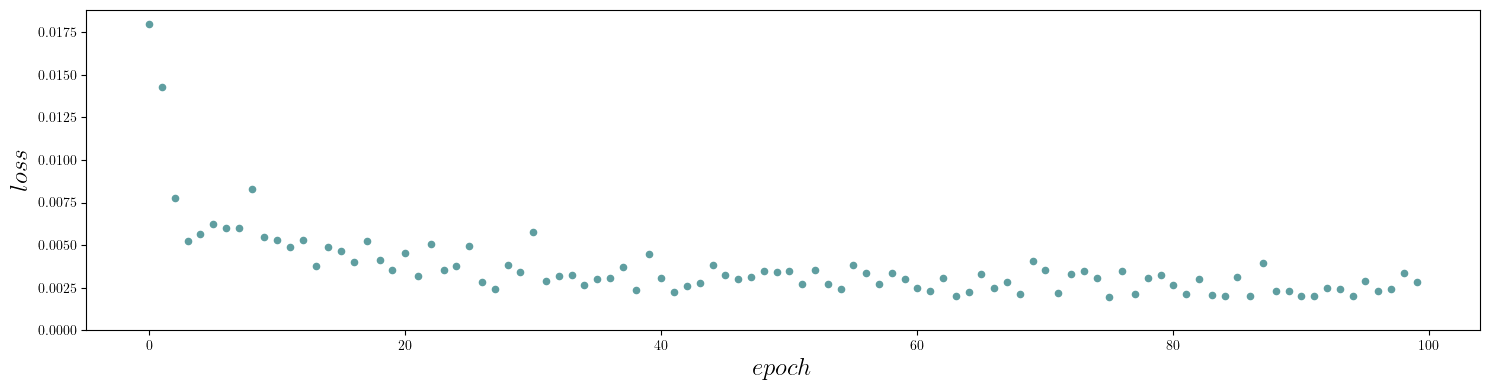

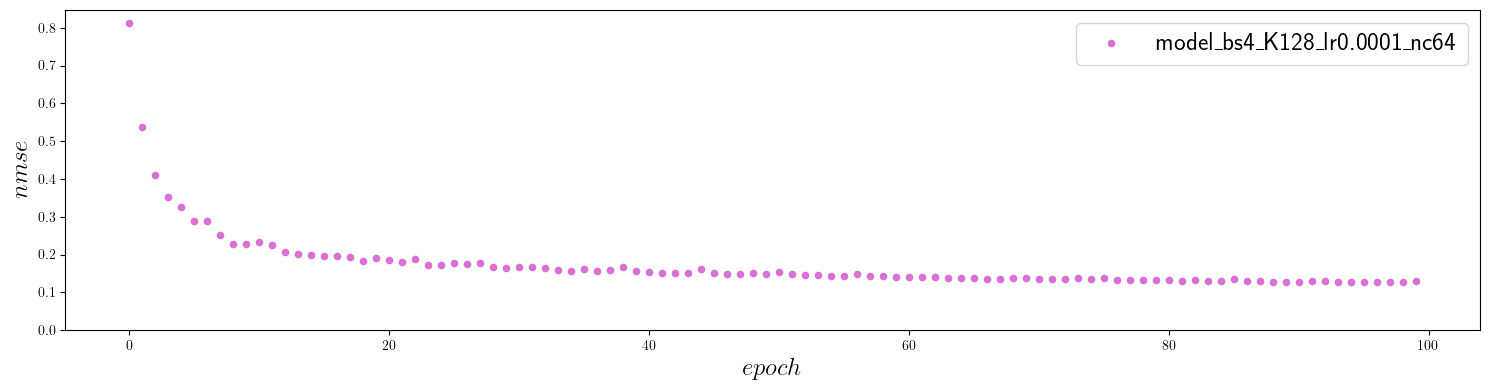

In [26]:
batch_size = 4
K = 128
lr = 1e-4
nc = 64
directory = f'{current_directory}/results/autoencoder/cnn/'
title = f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}'

from autoencoder_analysis import plot_info_training
sizes = plot_info_training(directory, title, i = 0, return_sizes = True)

In [28]:
from autoencoder import ConvolutionalAutoencoder_debug
X = simulation.X_rgb
x = np.swapaxes(torch.from_numpy(X), 0, 1).cpu()
x = x.float()
m = simulation.m
print(x.shape)
print(K)
print(batch_size)

def apply_autoencoder(K, batch_size, nc = 64, encoded = False, directory = f'{current_directory}/results/autoencoder/cnn/'):
    autoencoder = ConvolutionalAutoencoder_debug(device, sizes, K = K, n_channels = nc, bias = True)

    autoencoder.load_state_dict(torch.load(directory + f'model_bs{batch_size}_K{K}_lr{lr}_nc{nc}.pt'))
    autoencoder.eval()  # Set the model to evaluation mode


    with torch.no_grad():
        encoded_data = autoencoder.linear_encoder(torch.reshape(autoencoder.encoder(x.to(device)), (m, -1)))

    with torch.no_grad():
        decoded_data = autoencoder.decoder(torch.reshape(autoencoder.linear_decoder(encoded_data), (m, autoencoder.n_channels, sizes[-1][0], sizes[-1][1])))

    if encoded : 
        return decoded_data, encoded_data
    return decoded_data

decoded_data, encoded_data = apply_autoencoder(K, batch_size, encoded = True)

torch.Size([6249, 3, 81, 51])
128
4


In [32]:
X_decoded = np.swapaxes(np.swapaxes(np.swapaxes(decoded_data.cpu().numpy(),0,1), 1,2),2,3)
print(X_decoded.shape)

(3, 81, 51, 6249)


In [33]:
horizontal_fft = np.fft.fftn(X_decoded[0,:,:,:])
horizontal_fft = np.fft.fftshift(horizontal_fft)
vertical_fft = np.fft.fftn(X_decoded[1,:,:,:])
vertical_fft = np.fft.fftshift(vertical_fft)


horizontal_psd = np.abs(horizontal_fft)**2
vertical_psd = np.abs(vertical_fft)**2

turbulence_spectrum_decoded = horizontal_psd + vertical_psd

In [34]:
turbulence_spectrum_decoded_integrated = np.sum(turbulence_spectrum_decoded, axis=(0, 1))

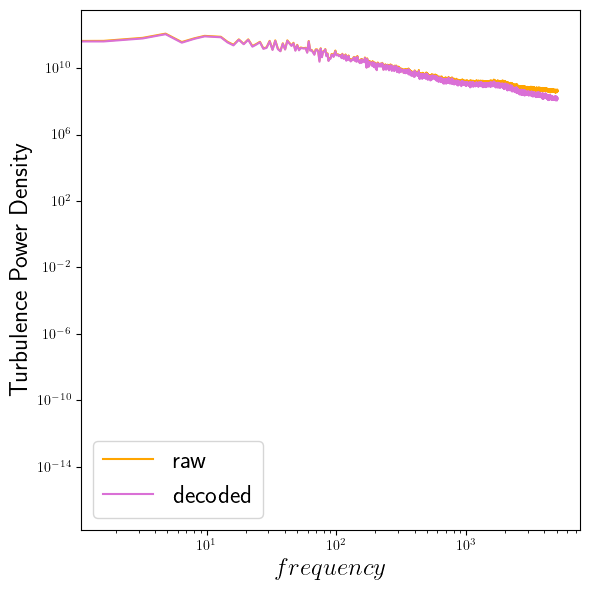

In [37]:
fig, ax1 = plt.subplots(figsize = (6,6))

ax1.plot(freqList, turbulence_spectrum_integrated, c = 'orange', label = 'raw')
ax1.plot(freqList, turbulence_spectrum_decoded_integrated, c = 'orchid', label = 'decoded')
ax1.set_ylabel(r'Turbulence Power Density', fontsize= fontsize)
ax1.set_xlabel(r'$frequency$', fontsize = fontsize)
ax1.legend(fontsize = fontsize)
ax1.set_yscale('log') 
ax1.set_xscale('log') 

fig.tight_layout()